In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

yaxisfont = 45
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18

import matplotlib.font_manager

def generate_plots(x_label_list, y_label_list, data, vmin, vmax, title, ylabel, xlabel, save_path, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(len(x_label_list) * 0.5, len(y_label_list) * 0.5))
    
    # Calculate extent based on data dimensions
    x_extent = [0.5, len(x_label_list) + 0.5]
    y_extent = [len(y_label_list) + 0.5, 0.5]
    
    # Use imshow with adjusted extent
    pos = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect='equal',
        origin='upper',
        extent=[x_extent[0], x_extent[1], y_extent[1], y_extent[0]]
    )
    
    plt.title(title, y=1.01, fontsize=bigfont)
    plt.xlabel(xlabel, fontsize=medfont)
    plt.ylabel(ylabel, fontsize=medfont)
    
    # Set ticks to match the center of each cell
    plt.yticks(
        range(1, len(y_label_list) + 1),
        y_label_list,
        fontsize=ticks_fontsize
    )
    plt.xticks(
        range(1, len(x_label_list) + 1),
        [int(item) for item in x_label_list],
        fontsize=ticks_fontsize
    )
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(pos, cax=cax)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')



def min_normalize(matrix, axis=1, topk=1):
    #print(matrix.shape)
    matrix_norm = matrix.copy()
    min_v = np.nanmin(matrix, axis=axis, keepdims=True)
    max_v = np.nanmax(matrix, axis=axis, keepdims=True)

    range_v = max_v - min_v
    range_v[range_v == 0] = 1  # 避免除以零
    
    # 归一化
    matrix_norm = (matrix - min_v) / range_v
    
    return matrix_norm

### sys-1

### Different Datanumber

In [2]:
import re
import numpy as np
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8 ,4, 2, 1] ##4096, 2048, 1024, 512
data_number_range = ['128', '256', '512', '1024', '2048', '4096', '8192', '16384', '32768']  #8', '16', '32', '64', 
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 

bsz = 128


exp_type = 'train'

In [3]:
k_range_list = []
for k_range in k_ranges:

    # if k_range[1] == 200.0:
    #     k_range_list.append(f'{k_range[0]}-{k_range[1]}')
    # else:
    if k_range[0]>=10.0:
        k_range_list.append(f'{int(k_range[0])}-')
    else:
        k_range_list.append(f'{k_range[0]}-')

In [4]:
exp_stats = {}

In [5]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 512:
                hyper_settings = f'bsz64_lr{lr}_subsample{subsamples}'
            elif subsamples == 1024:
                hyper_settings = f'bsz32_lr{lr}_subsample{subsamples}'
            elif subsamples == 2048:
                hyper_settings = f'bsz16_lr{lr}_subsample{subsamples}'
            elif subsamples == 4096:
                hyper_settings = f'bsz8_lr{lr}_subsample{subsamples}'
            else:
                hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            exp_stats[pde_settings][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_loss_by_seed = []
            ### average over seeds
            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                if subsamples in [4096, 2048, 1024, 512, 256]:
                    base_dir = './results_sameiteration/expts_eps1000'
                    stop_epoch = 999
                elif subsamples == 128:
                    base_dir = './results_sameiteration/expts_eps750'
                    stop_epoch = 749
                elif subsamples == 64:
                    base_dir = './results_sameiteration/expts_eps500'
                    stop_epoch = 499
                elif subsamples == 32:
                    base_dir = './results_sameiteration/expts_eps300'
                    stop_epoch = 299
                elif subsamples == 16:
                    base_dir = './results_sameiteration/expts_eps200'
                    stop_epoch = 199
                elif subsamples == 8:
                    base_dir = './results_sameiteration/expts_eps150'
                    stop_epoch = 149
                elif subsamples == 4:
                    base_dir = './results_sameiteration/expts_eps100'
                    stop_epoch = 99
                elif subsamples == 2:
                    base_dir = './results_sameiteration/expts_eps75'
                    stop_epoch = 74
                elif subsamples == 1:
                    base_dir = './results_sameiteration/expts_eps50'
                    stop_epoch = 49
                    
                    
                    
                best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs.txt'
                
       
                    
                ## read the txt
                test_err = 1e999
                train_loss = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'tr_err' in line:
                                train_loss = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            
                            if f'epoch,{stop_epoch}' in line:
                                break
                    
                    best_test_err_by_seed.append(test_err)
                    best_train_loss_by_seed.append(train_loss)
                except Exception as e:
                    pass
                    #print(f'Error reading {best_log}: {e}')
                
            #print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
            exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_mean'] = np.mean(best_train_loss_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_loss_std'] = np.std(best_train_loss_by_seed)

(9, 8)


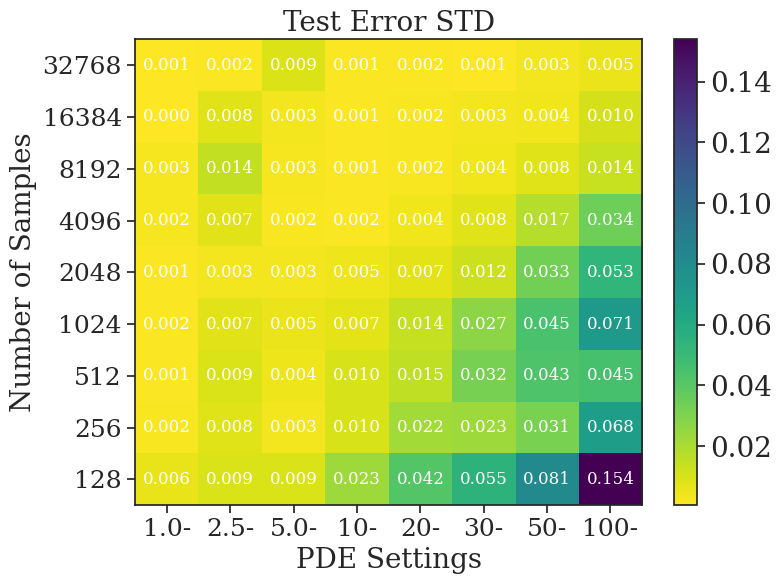

In [6]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 7x7 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['test_err_std'] #['test_err_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
#cbar.set_label("L2 Error", fontsize=cbar_fontsize)

plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=ticks_fontsize)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=ticks_fontsize)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

plt.title("Test Error STD", fontsize=bigfont) #, 4K Iterations
for i in range(loss.shape[0]):
    for j in range(loss.shape[1]):
        plt.text(j, i, f'{loss[i, j]:.3f}', ha='center', va='center', color='white')

    
    
plt.tight_layout()
plt.savefig('./plots/test_fno_diffepochs.png', dpi=1080, bbox_inches='tight')
plt.savefig('./plots/test_fno_diffepochs.pdf', bbox_inches='tight')

plt.show()

(9, 8)


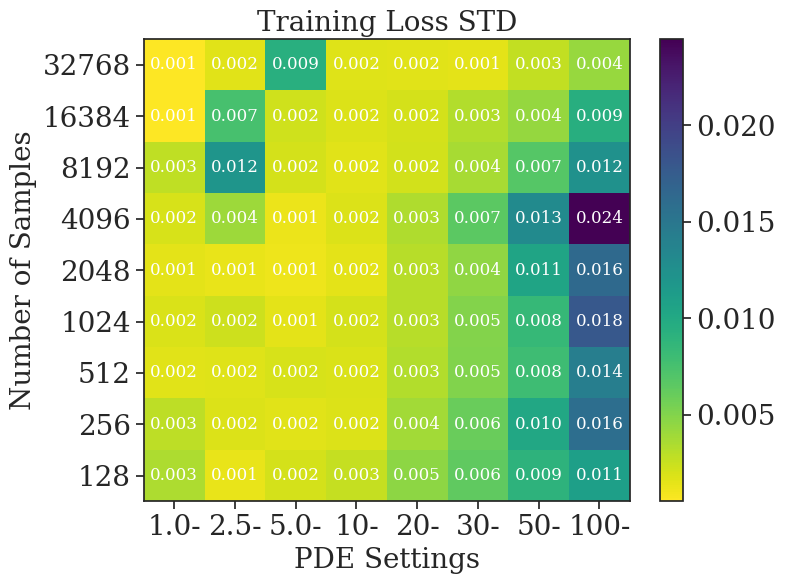

In [9]:
### 8 \times 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 8x8 zeros
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

 
for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:

        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['train_loss_std'] #['train_loss_mean']


from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(loss, aspect='auto', cmap='viridis_r', origin='lower')

cbar = plt.colorbar(heatmap)
#cbar.set_label("L2RE", fontsize=medfont)

plt.xticks(ticks=np.arange(len(pde_settings)), labels=pde_settings, fontsize=medfont)
plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
plt.xlabel("PDE Settings", fontsize=medfont)
plt.ylabel("Number of Samples", fontsize=medfont)

plt.title("Training Loss STD", fontsize=medfont) #, 4K Iterations

for i in range(loss.shape[0]):
    for j in range(loss.shape[1]):
        plt.text(j, i, f'{loss[i, j]:.3f}', ha='center', va='center', color='white')
        
plt.tight_layout()
plt.savefig('./plots/train_fno_diffepochs.png', dpi=1080, bbox_inches='tight')
plt.savefig('./plots/train_fno_diffepochs.pdf', bbox_inches='tight')

plt.show()

### Iteration settings

all data_number settings: 1K iterations

all data_number settings: 4000/2000/1000 iterations


In [8]:
## stop epochs
if subsamples == 32:
    stop_epoch = 499
elif subsamples == 16:
    stop_epoch = 249
elif subsamples == 8:
    stop_epoch = 124
elif subsamples == 4:
    stop_epoch = 63
elif subsamples == 2:
    stop_epoch = 31
else:
    stop_epoch = 999
    
    
## stop epochs
if subsamples == 128:
    stop_epoch = 499
elif subsamples == 64:
    stop_epoch = 249
elif subsamples == 32:
    stop_epoch = 124
elif subsamples == 16:
    stop_epoch = 63
elif subsamples == 8:
    stop_epoch = 31
elif subsamples == 4:
    stop_epoch = 15
elif subsamples == 2:
    stop_epoch = 7
else:
    stop_epoch = 999
    


if subsamples == 128:
    stop_epoch = 599
elif subsamples == 64:
    stop_epoch = 299
elif subsamples == 32:
    stop_epoch = 249
elif subsamples == 16:
    stop_epoch = 199
elif subsamples == 8:
    stop_epoch = 149
elif subsamples == 4:
    stop_epoch = 99
elif subsamples == 2:
    stop_epoch = 74
else:
    stop_epoch = 999


### same interations / epochs